# Policy-Gradient GFlowNets: from Trajectory Balance to Entropic PPO

Almost every GFlowNet objective in this library — TB, DB, SubTB, FM — works the same
way: write down a *flow-balance condition* that the true sampler must satisfy, then
regress its residual to zero.

This notebook takes a different route. With a **fixed backward policy**, GFlowNet
training is *exactly* an entropy-regularized RL problem, so you can throw the whole RL
policy-gradient toolbox at it: reward-to-go, learned baselines, GAE, and PPO. That is
the content of

> Zykova-Myzina, Gritsaev, Tiapkin & Morozov, **Proximal Policy Optimization for
> Amortized Discrete Sampling** ([arXiv:2606.15793](https://arxiv.org/abs/2606.15793)),

which derives **Ent-PPO**, the first PPO variant that actually works for GFlowNets, and
shows it converges faster and uses fewer reward evaluations than the balance objectives.

We will:

1. Build the GFlowNet $\leftrightarrow$ soft-RL dictionary and **verify it numerically** —
   the total soft return turns out to be the negated Trajectory Balance score.
2. Derive the policy gradient and its four advantage estimators, and **measure** how much
   variance each one removes.
3. Derive Ent-PPO and see where its KL trust region comes from (it is *not* a heuristic).
4. Watch the critic converge to $\log Z$ — the correspondence made visible.
5. Run Ent-PPO head-to-head against TB, DB and SubTB at equal reward evaluations.
6. Ablate the KL and the clipping, reproducing the paper's Figs. 7 and 8.
7. Learn the backward policy with Trajectory Likelihood Maximization.

Everything runs on CPU in a few minutes. The corresponding script is
`tutorials/examples/train_hypergrid_ppo.py`.

In [1]:
import time

import matplotlib.pyplot as plt
import torch

from gfn.estimators import DiscretePolicyEstimator, ScalarEstimator
from gfn.gflownet import (
    DBGFlowNet,
    EntPPOGFlowNet,
    PolicyGradientGFlowNet,
    SubTBGFlowNet,
    TBGFlowNet,
    tlm_loss,
)
from gfn.gym import HyperGrid
from gfn.preprocessors import KHotPreprocessor
from gfn.samplers import Sampler
from gfn.utils.modules import MLP, DiscreteUniform
from gfn.utils.prob_calculations import get_trajectory_pbs, get_trajectory_pfs
from gfn.utils.soft_rl import (
    gae_advantages,
    reward_to_go,
    soft_state_values,
    soft_step_returns,
    soft_step_rewards,
)

SEED = 0
NDIM, HEIGHT = 2, 16
BATCH_SIZE = 16          # trajectories per rollout, as in the paper's Appendix G
LR = 1e-3                # policy learning rate
LR_VALUE = LR / 3        # the paper's tuned value learning rate
LR_LOGZ = 1e-1           # TB's logZ wants a much larger step
GAE_LAMBDA = 0.7         # the paper's tuned lambda
N_ITERATIONS = 2000
EVAL_EVERY = 50           # exact evaluation is cheap, so measure often

torch.set_default_device("cpu")

## 1. The environment

A $16 \times 16$ HyperGrid: start at the corner $s_0 = (0, 0)$, step $+1$ along one axis
at a time, and exit whenever you like. Exiting is allowed from any cell, so all 256 cells
are terminating states $\mathcal{X}$, and the reward puts four sharp modes near the
corners. Because the space is small we can enumerate it, so we know the target $R(x)/Z$
exactly and can measure the **total variation distance** between it and what each method
actually samples.

`calculate_partition=True` also gives us the true $\log Z$, which we will need in §6.

In [2]:
env = HyperGrid(
    ndim=NDIM,
    height=HEIGHT,
    reward_fn_str="original",
    reward_fn_kwargs={"R0": 0.1, "R1": 0.5, "R2": 2.0},
    calculate_partition=True,
    store_all_states=True,
    validate_modes=False,
)
preprocessor = KHotPreprocessor(height=env.height, ndim=env.ndim)
TRUE_LOG_Z = float(env.log_partition())

print(f"terminating states : {env.n_terminating_states}")
print(f"true log Z         : {TRUE_LOG_Z:.4f}")


def make_estimators(seed=SEED, hidden_dim=256, n_hidden=2, learnable_pb=False):
    """Builds a fresh (PF, PB, logV) triple. The value net mirrors the policy encoder.

    P_B is uniform over parents unless `learnable_pb`, following the paper's Appendix G:
    it is held fixed everywhere except the TLM experiment in section 10.
    """
    torch.manual_seed(seed)
    pf = DiscretePolicyEstimator(
        MLP(preprocessor.output_dim, env.n_actions, hidden_dim, n_hidden),
        env.n_actions,
        preprocessor=preprocessor,
    )
    pb_module = (
        MLP(preprocessor.output_dim, env.n_actions - 1, hidden_dim, n_hidden)
        if learnable_pb
        else DiscreteUniform(output_dim=env.n_actions - 1)
    )
    pb = DiscretePolicyEstimator(
        pb_module,
        env.n_actions,
        preprocessor=preprocessor,
        is_backward=True,
    )
    logV = ScalarEstimator(
        MLP(preprocessor.output_dim, 1, hidden_dim, n_hidden), preprocessor=preprocessor
    )
    return pf, pb, logV

terminating states : 256
true log Z         : 4.1836


### Measuring the error exactly

The usual way to score a GFlowNet is to sample a few thousand terminating states and
compare the histogram to $R(x)/Z$. That estimator has a noise floor of its own, and on a
problem this small the floor is comparable to the differences between methods we are
trying to resolve — so we would end up plotting sampling noise.

Because the state space is enumerable we can skip sampling entirely. Push probability
mass forward through the DAG in topological order, and the exact terminating
distribution induced by $P_F$ falls out:

$$
u(s_0) = 1,\qquad
u(s') = \sum_{s \in \mathrm{Par}(s')} u(s)\, P_F(s' \mid s),\qquad
p(x) = u(x)\, P_F(s_f \mid x).
$$

torchgfn exposes this as `DiscreteEnv.exact_terminating_distribution`. It works for any
environment whose state space can be enumerated — which the environment tells you through
`env.is_enumerable`, since most interesting environments cannot. Under the hood it walks
the DAG in topological order (Kahn's algorithm over `forward_masks` and `env.step`), so it
is not HyperGrid-specific.

In [3]:
print(f"env.is_enumerable          : {env.is_enumerable}")
print(f"terminating states         : {env.n_terminating_states}")


def exact_tv(gflownet):
    """Total variation distance between the model and the target R(x)/Z."""
    pmf = env.exact_terminating_distribution(gflownet.pf)
    return 0.5 * (pmf - env.true_dist()).abs().sum().item()

env.is_enumerable          : True
terminating states         : 256


Two checks. First, that the exact computation is right: it should agree with the sampling
estimator once the sample is large enough. Second, that the floor is real — score a
*perfect* model, one that samples exactly from $R(x)/Z$, using the sampling estimator.
Its true error is zero, so whatever the estimator reports is pure noise.

In [4]:
pf_demo, pb_demo, _ = make_estimators()
demo_gfn = TBGFlowNet(pf=pf_demo, pb=pb_demo)
sampled = env.validate(demo_gfn, 200_000, check_sample_sufficiency=False)[0]["l1_dist"] / 2
print(f"untrained policy, exact TV            : {exact_tv(demo_gfn):.5f}")
print(f"untrained policy, sampled TV (200k)   : {sampled:.5f}")

true_dist = env.true_dist()
torch.manual_seed(SEED)
for n in (10_000, 100_000):
    draws = torch.multinomial(true_dist, n, replacement=True)
    histogram = torch.bincount(draws, minlength=len(true_dist)).float() / n
    floor = 0.5 * (histogram - true_dist).abs().sum().item()
    print(f"a PERFECT model scored with {n:>7,} samples : TV = {floor:.5f}")

untrained policy, exact TV            : 0.77972
untrained policy, sampled TV (200k)   : 0.78017
a PERFECT model scored with  10,000 samples : TV = 0.05558
a PERFECT model scored with 100,000 samples : TV = 0.01604


That last number is the point. A model with *zero* error scores around 0.06 when measured
with 10 000 samples, so any sampled comparison at that scale cannot distinguish a good
GFlowNet from a perfect one. Every curve below is therefore exact.

## 2. A GFlowNet is an entropy-regularized RL agent

Define an episodic MDP on the same DAG: the action at $s_t$ *is* the choice of a child
$s_{t+1}$, and an absorbing sink $s_f$ is appended so that terminated trajectories extend
to a common horizon. Give it the per-step reward (paper Eq. 7)

$$
r(s_t, s_{t+1}) = \begin{cases}
\log P_B(s_t \mid s_{t+1}), & s_t \notin \mathcal{X} \cup \{s_f\},\\
\log R(s_t),                & s_t \in \mathcal{X},\\
0,                          & s_t = s_f,
\end{cases}
$$

and measure a policy by its **soft** value, which pays a bonus for being random:

$$
V^\pi_\alpha(s) \triangleq \mathbb{E}_\pi\Big[\textstyle\sum_t \gamma^t\big(r(s_t,a_t) + \alpha\,\mathcal{H}(\pi(\cdot\mid s_t))\big) \,\Big|\, s_0 = s\Big].
$$

At $\alpha = \gamma = 1$ this is not an analogy, it is an identity. Tiapkin et al. show

$$
\mathrm{KL}\big(P_F \,\|\, P_B\big) = -V^{\pi_\theta}_{\alpha=1}(s_{\mathrm{init}}) + \log Z,
$$

so maximizing the soft value *is* minimizing the reverse KL that GFlowNet training
minimizes. At the optimum $V^{\pi^\star}(s_{\mathrm{init}}) = \log Z$ and the induced
terminal distribution is $R(x)/Z$. The full dictionary (their Table 1):

| GFlowNets | Soft RL |
|---|---|
| $P_F(s_{t+1} \mid s_t; \theta)$ | $\pi_\theta(s_{t+1} \mid s_t)$ |
| $\log P_B(s_t \mid s_{t+1})$ | $r(s_t, s_{t+1})$ |
| $\log R(s_t)$ | $r(s_t, s_f)$ |
| $\log Z$ | $V^{\pi^\star}_{\alpha=1}(s_{\mathrm{init}})$ |
| $\log \mathcal{F}(s_t)$ | $V^{\pi^\star}_{\alpha=1}(s_t)$ |
| $\log \mathcal{F}(s_t \to s_{t+1})$ | $Q^{\pi^\star}_{\alpha=1}(s_t, s_{t+1})$ |

Two things are worth pausing on, because getting either wrong is what sank earlier
attempts at PPO for GFlowNets:

- **The intermediate reward $\log P_B$ is essential.** Without it you have a sparse
  terminal-reward MDP, whose optimum is $\arg\max_x R(x)$, not $R(x)/Z$.
- **So is the entropy term.** It is fixed at $\alpha = 1$ by the correspondence; it is
  not a tunable exploration bonus.

The original GFlowNet paper tried PPO with neither, and reported mode collapse — exactly
what the theory predicts.

### Verifying the dictionary numerically

Write the **one-step soft return** (Eq. 9) as

$$
g_t = r_t - \log \pi_\theta(s_{t+1} \mid s_t),
$$

using $\mathbb{E}_{a \sim \pi}[-\log \pi(a\mid s)] = \mathcal{H}(\pi(\cdot\mid s))$ to put
the entropy on the sample path. Then summing over a whole trajectory,

$$
\sum_t g_t = \log R(x) + \log P_B(\tau \mid x) - \log P_F(\tau)
           = -\Big[\log \tfrac{P_F(\tau)}{P_B(\tau \mid x) R(x)}\Big],
$$

which is precisely the **negated Trajectory Balance score** that `TBGFlowNet.get_scores`
returns. TB then squares that residual after adding $\log Z$; the policy gradient instead
uses it directly as a reward signal — with $\log Z$ playing the role of a constant
baseline. Let's check the identity against the library's own TB implementation.

In [5]:
pf, pb, logV = make_estimators()
sampler = Sampler(estimator=pf)
trajectories = sampler.sample_trajectories(env, n=8, save_estimator_outputs=True)

with torch.no_grad():
    log_pf = get_trajectory_pfs(pf, trajectories)
    log_pb = get_trajectory_pbs(pb, trajectories)
    rewards = soft_step_rewards(trajectories, log_pb)      # Eq. 7
    g = soft_step_returns(log_pf, rewards)                 # Eq. 9
    tb_score = TBGFlowNet(pf=pf, pb=pb).get_scores(trajectories)

print("sum_t g_t   :", g.sum(dim=0).numpy().round(4))
print("-TB score   :", (-tb_score).numpy().round(4))
print("max |diff|  :", (g.sum(dim=0) + tb_score).abs().max().item())

sum_t g_t   : [2.3322 0.6081 4.1119 3.0954 0.6081 1.7405 3.0954 2.8677]
-TB score   : [2.3322 0.6081 4.1119 3.0954 0.6081 1.7405 3.0954 2.8677]
max |diff|  : 4.76837158203125e-07


The reward tensor also shows the structure of Eq. 7 directly: every non-exit step carries
$\log P_B$, and the single exit step of each trajectory carries $\log R(x)$.

In [6]:
is_exit = trajectories.actions.is_exit
exit_step = trajectories.terminating_idx - 1
which = torch.arange(trajectories.batch_size)

longest = int(trajectories.terminating_idx.argmax())
print(f"per-step rewards of the longest trajectory (index {longest}):")
for t in range(int(trajectories.terminating_idx[longest])):
    kind = "exit  -> log R(x)" if is_exit[t, longest] else "move  -> log P_B "
    print(f"  t={t}  {kind}  r = {rewards[t, longest]:+.4f}")

print()
print("log R(x) recovered from the exit steps:", rewards[exit_step, which].numpy().round(4))
print("trajectories.log_rewards            :", trajectories.log_rewards.numpy().round(4))

per-step rewards of the longest trajectory (index 0):
  t=0  move  -> log P_B   r = +0.0000
  t=1  move  -> log P_B   r = -0.6931
  t=2  move  -> log P_B   r = -0.6931
  t=3  move  -> log P_B   r = -0.6931
  t=4  move  -> log P_B   r = -0.6931
  t=5  move  -> log P_B   r = -0.6931
  t=6  move  -> log P_B   r = -0.6931
  t=7  exit  -> log R(x)  r = -2.3026

log R(x) recovered from the exit steps: [-2.3026 -0.5108 -0.5108 -0.5108 -0.5108 -0.5108 -0.5108 -0.5108]
trajectories.log_rewards            : [-2.3026 -0.5108 -0.5108 -0.5108 -0.5108 -0.5108 -0.5108 -0.5108]


The two GAE limits are worth checking too, since they are what the $\lambda$ knob
interpolates between: at $\lambda = 0$ the advantage is the one-step soft TD residual
$\delta_t = g_t + V(s_{t+1}) - V(s_t)$, and at $\lambda = 1$ it is reward-to-go minus the
baseline. Note $V_\varphi(s_f) = 0$ at the sink — that is what keeps the varying-horizon
return finite at $\gamma = 1$ — while terminating states get a real value estimate.

In [7]:
with torch.no_grad():
    values = soft_state_values(logV, trajectories)      # (T + 1, N), zero at the sink
deltas = g + values[1:] - values[:-1]                   # Eq. 12

print("lambda=0  ==  one-step TD residual  :",
      torch.allclose(gae_advantages(g, values, 0.0), deltas, atol=1e-6))
print("lambda=1  ==  reward-to-go - V(s_t) :",
      torch.allclose(gae_advantages(g, values, 1.0), reward_to_go(g) - values[:-1], atol=1e-5))
print("V at sink states is exactly zero    :",
      bool((values[trajectories.states.is_sink_state] == 0).all()))

lambda=0  ==  one-step TD residual  : True
lambda=1  ==  reward-to-go - V(s_t) : True
V at sink states is exactly zero    : True


## 3. Vanilla policy gradient, and four ways to spend variance

The policy gradient theorem (Eq. 8) gives

$$
\nabla_\theta \tilde{J}(\pi_\theta) = \mathbb{E}_{\pi_\theta}
   \Big[\textstyle\sum_t \nabla_\theta \log \pi_\theta(s_{t+1}\mid s_t)\, \Psi_t\Big],
$$

and every choice of $\Psi_t$ below is unbiased (or controllably biased) — they differ
only in **variance**, which is what actually determines how fast you learn:

| `advantage=` | $\Psi_t$ | Idea |
|---|---|---|
| `"total"` | $\sum_k g_k$ | The whole soft return, identical at every step. This is REINFORCE on the reverse KL — and, per §2, TB's residual with $\log Z$ as a constant baseline. |
| `"reward_to_go"` | $\hat{R}_t = \sum_{k \geq t} g_k$ | Rewards collected *before* step $t$ cannot depend on the action at $t$, so they contribute zero in expectation. Drop them. |
| `"baseline"` | $\hat{R}_t - V_\varphi(s_t)$ | Subtracting any function of the state alone preserves unbiasedness. The on-policy soft value removes the trajectory-level component shared by all actions at $s_t$. |
| `"gae"` | $\sum_k \lambda^k \delta_{t+k}$ | Generalized Advantage Estimation over soft TD residuals $\delta_t = g_t + V_\varphi(s_{t+1}) - V_\varphi(s_t)$, with $V_\varphi(s_f) := 0$. $\lambda = 1$ recovers the row above; $\lambda = 0$ collapses to one-step TD — low variance, biased whenever $V_\varphi \neq \tilde{V}^{\pi_\theta}$. |

$\Psi_t$ is always **detached**: the score-function identity guarantees gradients flowing
through it vanish in expectation.

### Measuring the variance

The cleanest way to see the ordering is to hold the policy *and* the critic fixed, then
compute the gradient many times on independent rollouts and look at how much the estimates
scatter. We train briefly first so the critic is a meaningful baseline rather than noise,
then evaluate all four estimators **at the same parameters**.

In [8]:
def batch_splits(batch, n_splits):
    """Yields `n_splits` random mini-batches; slicing carries the frozen targets along."""
    for chunk in torch.randperm(len(batch)).chunk(n_splits):
        if len(chunk) > 0:
            yield batch[chunk]


def warm_up(gflownet, n_iterations, lr=LR, lr_value=LR_VALUE, seed=SEED):
    """Trains a policy-gradient GFlowNet briefly so its critic is informative."""
    torch.manual_seed(seed)
    sampler = Sampler(estimator=gflownet.pf)
    policy_opt = torch.optim.Adam(gflownet.pf.parameters(), lr=lr)
    value_opt = torch.optim.Adam(gflownet.logV_parameters(), lr=lr_value)
    for _ in range(n_iterations):
        traj = sampler.sample_trajectories(env, n=BATCH_SIZE, save_estimator_outputs=True)
        batch = gflownet.to_training_samples(traj)
        policy_opt.zero_grad()
        gflownet.policy_loss(batch).backward()
        policy_opt.step()
        for split in batch_splits(batch, 2):
            value_opt.zero_grad()
            gflownet.value_loss(env, split).backward()
            value_opt.step()
    return gflownet


pf, pb, logV = make_estimators()
_ = warm_up(
    PolicyGradientGFlowNet(pf=pf, pb=pb, logV=logV, advantage="gae", gae_lambda=GAE_LAMBDA),
    n_iterations=500,
)
print("warm-up done")

warm-up done


In [9]:
def gradient_scatter(advantage, pf, pb, logV, n_batches=64, seed=123):
    """Trace of the covariance of the policy gradient across independent rollouts."""
    uses_value = advantage in ("baseline", "gae")
    gflownet = PolicyGradientGFlowNet(
        pf=pf,
        pb=pb,
        logV=logV if uses_value else None,
        advantage=advantage,
        gae_lambda=GAE_LAMBDA,
    )
    torch.manual_seed(seed)  # Same rollouts for every estimator.
    sampler = Sampler(estimator=pf)
    grads = []
    for _ in range(n_batches):
        traj = sampler.sample_trajectories(env, n=BATCH_SIZE)
        batch = gflownet.to_training_samples(traj)
        gflownet.zero_grad()
        gflownet.policy_loss(batch).backward()
        grads.append(torch.cat([p.grad.flatten() for p in pf.parameters()]))
    return torch.stack(grads).var(dim=0).sum().item()


ESTIMATORS = ["total", "reward_to_go", "baseline", "gae"]
scatter = {name: gradient_scatter(name, pf, pb, logV) for name in ESTIMATORS}
baseline_scatter = scatter["total"]
for name in ESTIMATORS:
    print(f"{name:>14}:  tr Cov = {scatter[name]:10.4f}   ({scatter[name] / baseline_scatter:6.1%} of 'total')")

         total:  tr Cov =   200.2089   (100.0% of 'total')
  reward_to_go:  tr Cov =    61.4960   ( 30.7% of 'total')
      baseline:  tr Cov =     0.5592   (  0.3% of 'total')
           gae:  tr Cov =     0.0826   (  0.0% of 'total')


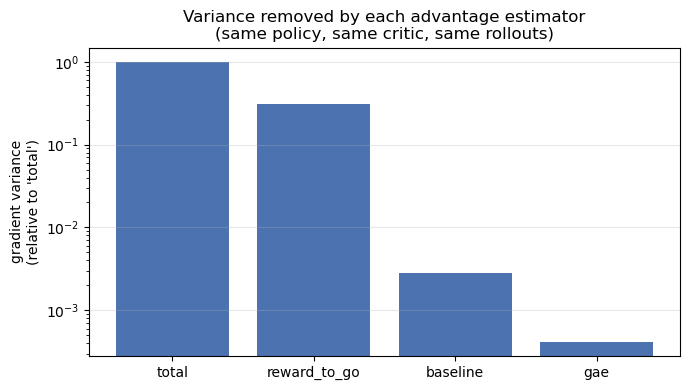

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ESTIMATORS, [scatter[n] / baseline_scatter for n in ESTIMATORS], color="#4C72B0")
ax.set_ylabel("gradient variance\n(relative to 'total')")
ax.set_title("Variance removed by each advantage estimator\n(same policy, same critic, same rollouts)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The ordering matches the RL literature and the paper's Section 5.2: each refinement strips
out another chunk of variance. Whether that translates into better *sampling* is the next
question.

## 4. One training loop for everything

To compare objectives honestly they must see the same number of **reward evaluations** —
that is the expensive resource in real GFlowNet applications (docking scores, simulators,
oracles), not gradient steps. The loop below counts sampled trajectories and is shared by
every method in this notebook.

The policy-gradient path follows the paper's Algorithm 2:

1. roll out a batch under the current policy;
2. **freeze** the soft rewards, advantages, value targets and $\log \pi_{\text{old}}$ for
   that batch (`to_training_samples`) — recomputing them against a moving $V_\varphi$
   would change the objective mid-update;
3. take $K$ policy steps on the frozen batch;
4. fit the critic for $E$ epochs of $S$ mini-batches.

The balance objectives (TB, DB, SubTB) take $K$ steps on the same batch too, so the
comparison is like-for-like — those losses are off-policy, so this is legitimate for them.

In [11]:
def train(
    gflownet,
    *,
    n_iterations=N_ITERATIONS,
    K=1,
    E=4,
    S=2,
    lr=LR,
    lr_value=LR_VALUE,
    learn_pb=None,
    seed=SEED,
    label="",
):
    """Trains any GFlowNet and records TV distance against reward evaluations."""
    torch.manual_seed(seed)
    is_pg = isinstance(gflownet, PolicyGradientGFlowNet)
    sampler = Sampler(estimator=gflownet.pf)

    groups = [{"params": list(gflownet.pf.parameters()), "lr": lr}]
    if not is_pg:  # Balance objectives train their scalar estimators jointly.
        if getattr(gflownet, "logz_parameters", list)():
            groups.append({"params": gflownet.logz_parameters(), "lr": LR_LOGZ})
        if hasattr(gflownet, "logF_parameters"):
            groups.append({"params": gflownet.logF_parameters(), "lr": lr})
    policy_opt = torch.optim.Adam(groups)
    value_opt = (
        torch.optim.Adam(gflownet.logV_parameters(), lr=lr_value)
        if is_pg and gflownet.logV is not None
        else None
    )
    pb_opt = torch.optim.Adam(gflownet.pb.parameters(), lr=lr) if learn_pb else None

    history = {"reward_evaluations": [], "tv": [], "label": label}
    reward_evaluations = 0
    start = time.time()

    for it in range(n_iterations):
        traj = sampler.sample_trajectories(env, n=BATCH_SIZE, save_estimator_outputs=is_pg)
        reward_evaluations += BATCH_SIZE

        if is_pg:
            batch = gflownet.to_training_samples(traj)
            for _ in range(K):
                policy_opt.zero_grad()
                gflownet.policy_loss(batch).backward()
                torch.nn.utils.clip_grad_norm_(gflownet.pf.parameters(), 1.0)
                policy_opt.step()
            if value_opt is not None:
                for _ in range(E):
                    for split in batch_splits(batch, S):
                        value_opt.zero_grad()
                        gflownet.value_loss(env, split).backward()
                        value_opt.step()
        else:
            for _ in range(K):
                policy_opt.zero_grad()
                gflownet.loss_from_trajectories(env, traj).backward()
                torch.nn.utils.clip_grad_norm_(gflownet.parameters(), 1.0)
                policy_opt.step()

        if pb_opt is not None:  # Ent-PPO admits no joint forward/backward loss; see 8.
            pb_opt.zero_grad()
            tlm_loss(gflownet.pb, traj).backward()
            pb_opt.step()

        if (it + 1) % EVAL_EVERY == 0:
            history["reward_evaluations"].append(reward_evaluations)
            history["tv"].append(exact_tv(gflownet))

    print(f"{label:<28} final TV = {history['tv'][-1]:.4f}   ({time.time() - start:.0f}s)")
    return history


def plot(histories, title, ax=None):
    """Plots TV distance against reward evaluations."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    for h in histories:
        ax.plot(h["reward_evaluations"], h["tv"], label=h["label"], linewidth=2)
    ax.set_xlabel("reward evaluations")
    ax.set_ylabel("total variation distance")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

## 5. Does lower variance mean better sampling?

Same budget, same architecture, same learning rate — only $\Psi_t$ changes.

In [12]:
vpg_histories = []
for name in ESTIMATORS:
    pf_i, pb_i, logV_i = make_estimators()
    uses_value = name in ("baseline", "gae")
    vpg_histories.append(
        train(
            PolicyGradientGFlowNet(
                pf=pf_i,
                pb=pb_i,
                logV=logV_i if uses_value else None,
                advantage=name,
                gae_lambda=GAE_LAMBDA,
            ),
            label=f"VPG ({name})",
        )
    )

VPG (total)                  final TV = 0.2491   (29s)


VPG (reward_to_go)           final TV = 0.1885   (33s)


VPG (baseline)               final TV = 0.0136   (60s)


VPG (gae)                    final TV = 0.0183   (59s)


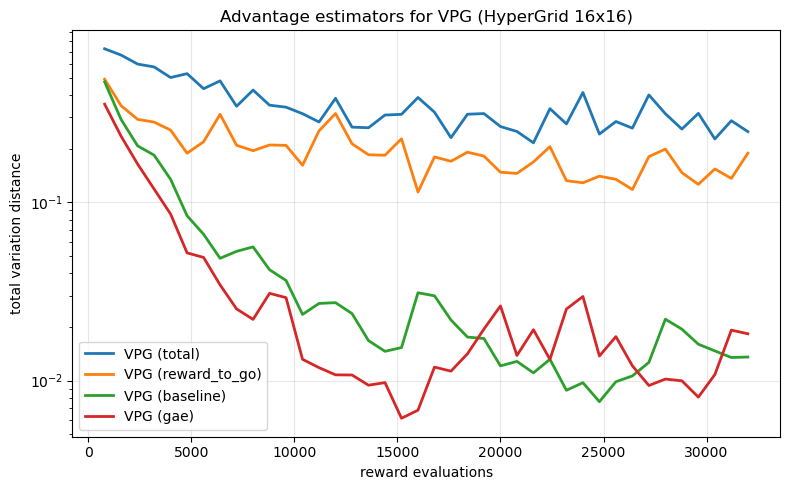

In [13]:
plot(vpg_histories, "Advantage estimators for VPG (HyperGrid 16x16)")
plt.tight_layout()
plt.show()

Yes, and by more than an order of magnitude on the same 32 000 reward evaluations. The
jump is almost entirely the **learned baseline**: reward-to-go alone improves only
modestly on the full return, while subtracting $V_\varphi(s_t)$ cuts the error by more
than a factor of ten. GAE and the plain baseline land close to each other — see §8 for why
differences that small should not be read as an ordering.

## 6. The critic is the log-flow — and $V(s_0)$ is $\log Z$

Look back at the dictionary: $\tilde{V}^{\pi^\star}(s) = \log \mathcal{F}(s)$ and
$\tilde{V}^{\pi^\star}(s_{\mathrm{init}}) = \log Z$. The value network we trained purely
as a variance-reduction baseline is the *same object* DB and SubTB call `logF` — and its
value at the initial state is the quantity TB learns as an explicit `logZ` parameter.

Nothing in the objective asks for this. It falls out of the correspondence.

In [14]:
pf, pb, logV = make_estimators()
critic_gfn = PolicyGradientGFlowNet(
    pf=pf, pb=pb, logV=logV, advantage="gae", gae_lambda=GAE_LAMBDA
)
critic_history = train(critic_gfn, label="VPG (gae), tracking V(s0)")

with torch.no_grad():
    learned_log_z = float(logV(env.reset(batch_shape=(1,))).squeeze())
print(f"\nlearned V(s0) : {learned_log_z:.4f}")
print(f"true    log Z : {TRUE_LOG_Z:.4f}")
print(f"absolute error: {abs(learned_log_z - TRUE_LOG_Z):.4f}")

VPG (gae), tracking V(s0)    final TV = 0.0183   (61s)

learned V(s0) : 4.1404
true    log Z : 4.1836
absolute error: 0.0432


### Two ways to fit the critic

The default is plain MSE regression onto the frozen targets $y_t$. The paper also
evaluates the **Sub-EB** objective (their Eqs. 14-15), from Morozov et al., which replaces
that regression with a balance condition on $V_\varphi$:

$$
\mathcal{L}_V(\varphi) = \mathbb{E}_{P_F(\tau)}\Big[\textstyle\sum_{i<j} w_{j-i}\,
\Big(\log \tfrac{P_F(\tau_{i:j}\mid s_i)\,e^{V_\varphi(s_i)}}
                {P_B(\tau_{i:j}\mid s_j)\,e^{V_\varphi(s_j)}}\Big)^2\Big].
$$

Read that carefully and it *is* the SubTB loss with $\log \mathcal{F}$ replaced by $V$ and
$\theta$ held frozen — which is exactly how `critic_loss="sub_eb"` is implemented here: it
reuses `SubTBGFlowNet` with detached policy log-probabilities rather than reimplementing
the sub-trajectory bookkeeping. The paper finds it slightly *worse* than plain GAE, so it
ships as an option, not the default.

VPG (gae), Sub-EB critic     final TV = 0.0110   (131s)


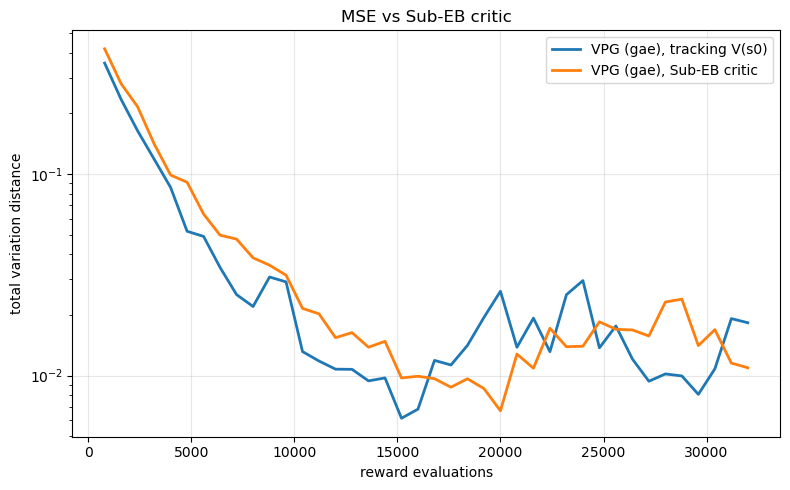

In [15]:
pf, pb, logV = make_estimators()
sub_eb_history = train(
    PolicyGradientGFlowNet(
        pf=pf,
        pb=pb,
        logV=logV,
        advantage="gae",
        gae_lambda=GAE_LAMBDA,
        critic_loss="sub_eb",
    ),
    label="VPG (gae), Sub-EB critic",
)

plot([critic_history, sub_eb_history], "MSE vs Sub-EB critic")
plt.tight_layout()
plt.show()

Sub-EB comes out slightly *ahead* of MSE regression in this run, and slightly behind it
in another run of the same notebook — the two are not separated at this budget. The paper
reports Sub-EB marginally worse, which is why it ships as an option rather than the
default. It is also appreciably slower, since it forms residuals over every
sub-trajectory rather than every step.

## 7. Entropic PPO: where the KL comes from

Everything so far takes **one** gradient step per rollout. PPO's whole point is to take
several — reusing each expensive batch — while bounding how far the policy can drift from
the one that generated it.

Start from the soft policy improvement operator at $\alpha = 1$, which at every state
returns the maximizer of

$$
\mathcal{G}^{\pi_{\text{old}}}(\pi; s) = \mathbb{E}_{a \sim \pi}\big[\tilde{Q}^{\pi_{\text{old}}}(s,a)\big] + \mathcal{H}(\pi(\cdot\mid s)).
$$

Rewrite $\tilde{Q}$ using the soft-advantage identity
$\tilde{Q}^{\pi_{\text{old}}} = \tilde{A}^{\pi_{\text{old}}} + \tilde{V}^{\pi_{\text{old}}} + \log \pi_{\text{old}}$
and drop the $\theta$-independent $\tilde{V}$ term:

$$
\mathcal{G}^{\pi_{\text{old}}}(\pi_\theta; s_t) \;\stackrel{c}{=}\;
\mathbb{E}_{\pi_\theta}\big[\tilde{A}^{\pi_{\text{old}}}(s_t, s')\big]
+ \underbrace{\mathbb{E}_{\pi_\theta}\big[\log \pi_{\text{old}}(s'\mid s_t)\big] + \mathcal{H}(\pi_\theta(\cdot\mid s_t))}_{= \;-\,\mathrm{KL}(\pi_\theta \,\|\, \pi_{\text{old}})}.
$$

**The cross-entropy against $\pi_{\text{old}}$ and the entropy bonus fuse into a KL.** It
is a two-sided trust region that soft policy improvement hands you for free — the same job
clipping does stochastically in standard PPO, but analytic. Importance-weighting the
advantage term and clipping the ratio as usual gives the final objective (Eq. 20):

$$
\ell_t^{\mathrm{Ent}}(\theta) = \mathrm{PPOClip}\big(\rho_t(\theta), \hat{A}_t\big)
   - \mathrm{KL}\big(\pi_\theta(\cdot\mid s_t)\,\|\,\pi_{\text{old}}(\cdot\mid s_t)\big),
\qquad \rho_t = \frac{\pi_\theta(a_t\mid s_t)}{\pi_{\text{old}}(a_t\mid s_t)}.
$$

Compare with standard PPO, which maximizes
$\mathrm{PPOClip}(\rho_t, A_t) + c_2\,\mathcal{H}(\pi_\theta)$. Three differences, all
consequences of the correspondence rather than tuning choices: the advantage is *soft*;
the entropy coefficient is pinned at $\alpha = 1$ instead of being a free $c_2$; and the
entropy is paired with a cross-entropy against $\pi_{\text{old}}$.

### Watching the trust region work

Freeze one rollout and take repeated steps on it. At epoch 0 we have $\pi_\theta = \pi_{\text{old}}$
exactly, so $\rho \equiv 1$ and $\mathrm{KL} \equiv 0$ — Ent-PPO's first inner step *is* the
VPG(GAE) step. As the epochs accumulate, the ratio drifts, the clip starts binding, and
the KL penalty grows to push back.

We can read the KL term straight off the public API: the difference between the loss with
and without `use_kl` is exactly the summed KL.

In [16]:
pf, pb, logV = make_estimators()
ppo = EntPPOGFlowNet(pf=pf, pb=pb, logV=logV, gae_lambda=GAE_LAMBDA)
warm_up(ppo, n_iterations=300)

# Same estimators, KL term switched off: the loss difference isolates the KL.
ppo_no_kl = EntPPOGFlowNet(pf=pf, pb=pb, logV=logV, gae_lambda=GAE_LAMBDA, use_kl=False)

torch.manual_seed(SEED)
frozen = ppo.to_training_samples(
    Sampler(estimator=pf).sample_trajectories(env, n=256, save_estimator_outputs=True)
)
optimizer = torch.optim.Adam(pf.parameters(), lr=LR)

epochs, kls, drifts, clipped = [], [], [], []
for k in range(24):
    with torch.no_grad():
        log_pf_new = get_trajectory_pfs(pf, frozen)
        valid = ~frozen.actions.is_dummy
        ratio = torch.exp(log_pf_new - frozen.log_probs)[valid]
        kl = (ppo.policy_loss(frozen) - ppo_no_kl.policy_loss(frozen)).item()
    epochs.append(k)
    kls.append(kl)
    drifts.append((ratio - 1).abs().mean().item())
    clipped.append(((ratio - 1).abs() > ppo.clip_eps).float().mean().item())

    optimizer.zero_grad()
    ppo.policy_loss(frozen).backward()
    optimizer.step()

print(f"epoch  0: KL = {kls[0]:.2e}   mean |rho - 1| = {drifts[0]:.2e}   clipped = {clipped[0]:.1%}")
print(f"epoch 23: KL = {kls[-1]:.2e}   mean |rho - 1| = {drifts[-1]:.2e}   clipped = {clipped[-1]:.1%}")

epoch  0: KL = 0.00e+00   mean |rho - 1| = 0.00e+00   clipped = 0.0%
epoch 23: KL = 9.78e-03   mean |rho - 1| = 2.42e-02   clipped = 0.6%


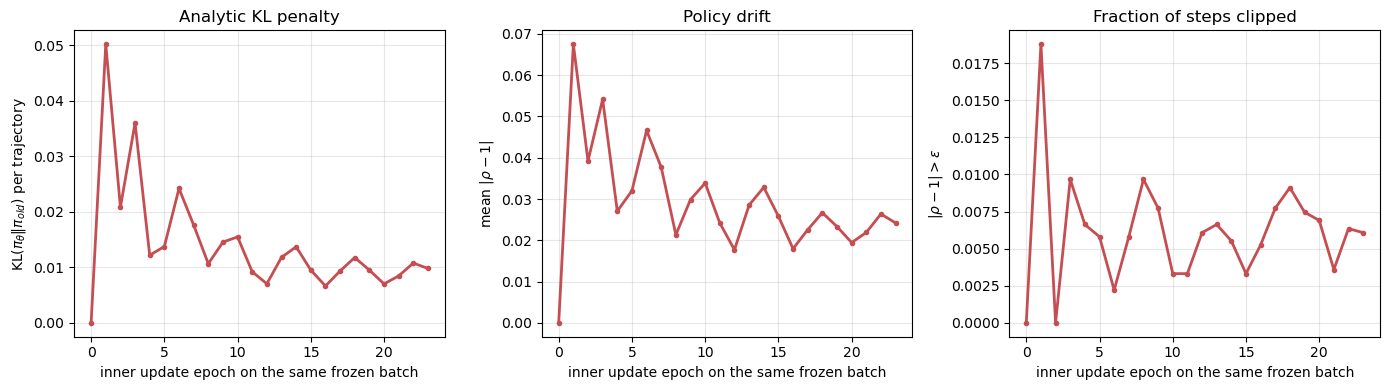

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, series, title, ylabel in [
    (axes[0], kls, "Analytic KL penalty", r"KL$(\pi_\theta \| \pi_{old})$ per trajectory"),
    (axes[1], drifts, "Policy drift", r"mean $|\rho - 1|$"),
    (axes[2], clipped, "Fraction of steps clipped", r"$|\rho - 1| > \epsilon$"),
]:
    ax.plot(epochs, series, marker="o", markersize=3, linewidth=2, color="#C44E52")
    ax.set_xlabel("inner update epoch on the same frozen batch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

All three start at exactly zero and grow together — which is the trust region doing its
job: as the policy leaves the neighbourhood of $\pi_{\text{old}}$, the KL penalty and the
clip both start resisting.

## 8. Head-to-head at equal reward evaluations

Now the comparison the paper is really about: Ent-PPO with $K \in \{1, 2, 4\}$ update
epochs against TB, DB and SubTB. Every method sees the same trajectories; Ent-PPO simply
extracts more gradient signal from each one. Note that $K = 1$ is by construction
VPG(GAE).

In [18]:
histories = []
for K in (1, 2, 4):
    pf_i, pb_i, logV_i = make_estimators()
    histories.append(
        train(
            EntPPOGFlowNet(pf=pf_i, pb=pb_i, logV=logV_i, gae_lambda=GAE_LAMBDA),
            K=K,
            label=f"Ent-PPO (K={K})",
        )
    )

pf_i, pb_i, _ = make_estimators()
histories.append(train(TBGFlowNet(pf=pf_i, pb=pb_i), label="TB"))

pf_i, pb_i, logF_i = make_estimators()
histories.append(train(DBGFlowNet(pf=pf_i, pb=pb_i, logF=logF_i), label="DB"))

pf_i, pb_i, logF_i = make_estimators()
histories.append(train(SubTBGFlowNet(pf=pf_i, pb=pb_i, logF=logF_i), label="SubTB"))

Ent-PPO (K=1)                final TV = 0.0213   (55s)


Ent-PPO (K=2)                final TV = 0.0294   (55s)


Ent-PPO (K=4)                final TV = 0.0323   (65s)


TB                           final TV = 0.0231   (28s)


DB                           final TV = 0.0123   (33s)


SubTB                        final TV = 0.0304   (41s)


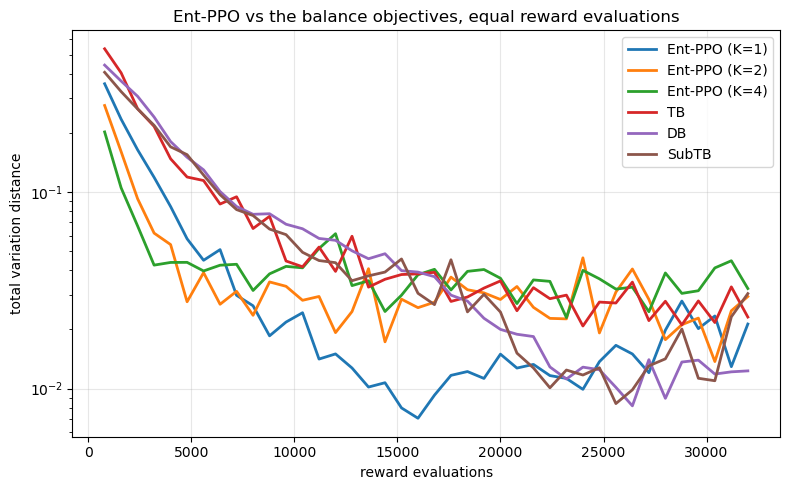

In [19]:
plot(histories, "Ent-PPO vs the balance objectives, equal reward evaluations")
plt.tight_layout()
plt.show()

### What actually happened — and what did not

Every method here lands between roughly 0.012 and 0.032, and the *ordering within that
band moves between runs*. An earlier run of this same notebook, differing only in the
fixed backward policy, put SubTB comfortably first at 0.0065; here SubTB is near the back
and DB is first. Measuring exactly removed the **measurement** noise, but it did nothing
about the **training** noise, and with a single seed these gaps are not resolvable. Read
the band, not the ranking.

Two things do survive that caveat.

**Ent-PPO does not clearly beat the balance objectives at this scale.** The paper reports
it ahead of all three on Hypergrid; here it is inside the pack.

**Increasing $K$ consistently hurts.** This one is monotone in $K$ within this run and
reproduced in the earlier run too, so unlike the ranking above it is unlikely to be noise.
The paper finds the opposite, most strongly on its largest problems.

Three differences make this the least favourable possible test of those claims:

- **Budget.** 32 000 trajectories is about 6% of the paper's Hypergrid budget
  ($5 \times 10^5$). Extra epochs on each batch are a way to squeeze more out of scarce
  data; early in training, with data still plentiful relative to how far the policy has
  moved, they mostly overfit the current batch.
- **Scale.** 256 terminating states, against $d=4, H=20$ — 160 000 — in the paper. Its
  own message is that Ent-PPO's advantage *grows* with problem size, with the largest gaps
  on sEH and graph-QM9.
- **Seeds.** One, against the paper's three with min–max bands. Differences of this size
  between neighbouring $K$ values are not obviously outside seed noise.

There is also a cost asymmetry worth naming: Ent-PPO does $K$ forward passes per rollout.
That trade only pays when reward evaluation dominates, and on HyperGrid the reward is a
closed-form expression — the regime where these methods should look *worst*.

## 9. Both corrections are load-bearing

The paper's central claim is that the KL is not a minor refinement. Push $K$ up to 8 and
remove one term at a time:

- **Without the KL** (`use_kl=False`), Ent-PPO degenerates to naive PPO on the soft reward.
  The entropy correction that pins the optimum at $R(x)/Z$ is gone, and with many update
  epochs it drifts (their Fig. 7).
- **Without the clip** (`use_clipping=False`), the optimum is still right — the KL takes
  care of that — but nothing bounds the *per-sample* importance ratio, whose fluctuations
  destabilize the gradient estimator (their Fig. 8).

They fix different problems, which is why you need both.

In [20]:
ablations = []
for label, kwargs in [
    ("Ent-PPO (K=8)", {}),
    ("no KL  (naive PPO)", {"use_kl": False}),
    ("no clipping", {"use_clipping": False}),
]:
    pf_i, pb_i, logV_i = make_estimators()
    ablations.append(
        train(
            EntPPOGFlowNet(pf=pf_i, pb=pb_i, logV=logV_i, gae_lambda=GAE_LAMBDA, **kwargs),
            K=8,
            n_iterations=1500,
            label=label,
        )
    )

Ent-PPO (K=8)                final TV = 0.0431   (71s)


no KL  (naive PPO)           final TV = 0.0935   (73s)


no clipping                  final TV = 0.0293   (73s)


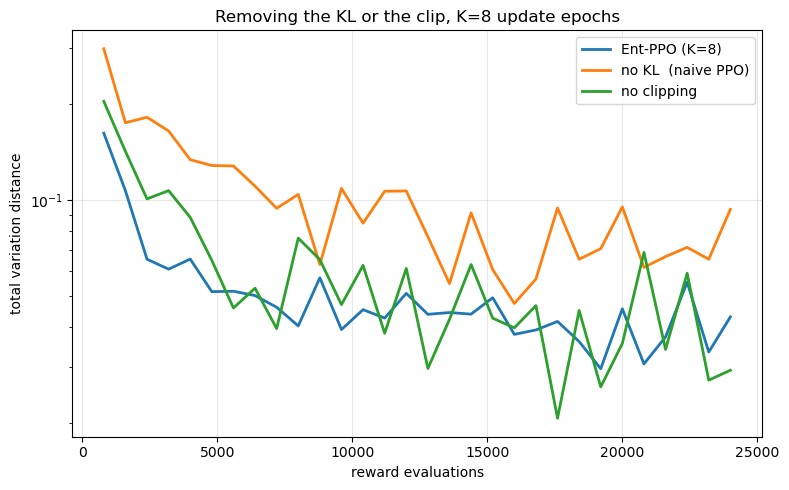

In [21]:
plot(ablations, "Removing the KL or the clip, K=8 update epochs")
plt.tight_layout()
plt.show()

The KL claim reproduces cleanly, and it is the one ablation whose effect is far larger
than the run-to-run spread: removing it roughly doubles the final error, in both this run
and the earlier one.

The clipping claim does not separate at all — here removing the clip is marginally
*better*, which given §8 simply means the two are indistinguishable at this budget. The
paper reports outright divergence without clipping, but at $K \in \{16, 32\}$, which we
never reach. This notebook confirms the paper's central claim about the KL and is not a
strong enough test of the clipping one.

## 10. Learning the backward policy

One caveat comes with the whole soft-RL framing. The correspondence of §2 requires
$P_B$ to be **fixed**: it defines the MDP reward, so changing it changes the problem
underneath the agent. That means Ent-PPO — unlike TB, DB and SubTB — admits no joint
forward/backward objective.

The workaround is **Trajectory Likelihood Maximization** (their Eq. 24), which fits $P_B$
to the trajectory distribution the current $P_F$ induces, as a separate update:

$$
\mathrm{TLM} = -\mathbb{E}_{\tau \sim P_F}\Big[\textstyle\sum_t \log P_B(s_t \mid s_{t+1}, \varphi)\Big],
\qquad \nabla_\varphi \mathrm{TLM} = \nabla_\varphi \mathrm{KL}(P_F \,\|\, P_B).
$$

It touches no rewards, works with any of the objectives here, and is exposed as
`gfn.gflownet.tlm_loss`.

Ent-PPO (K=4), fixed uniform P_B final TV = 0.0323   (80s)


Ent-PPO (K=4), TLM-learned P_B final TV = 0.0451   (85s)


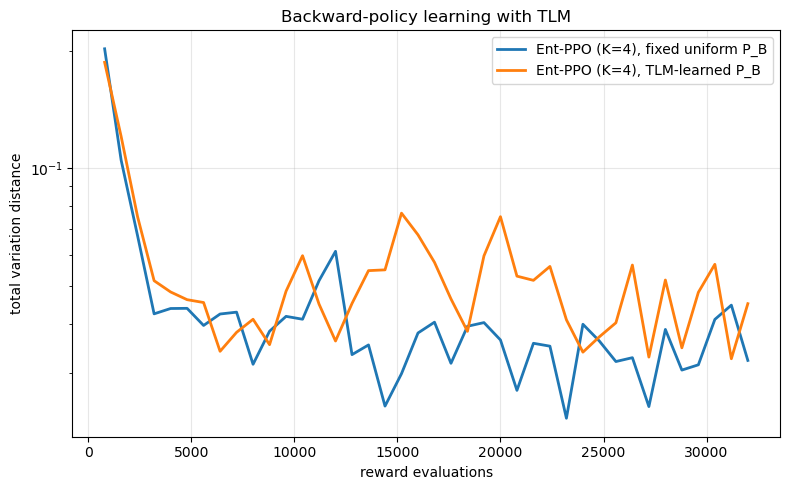

In [22]:
pb_histories = []
for label, learn_pb in [
    ("Ent-PPO (K=4), fixed uniform P_B", None),
    ("Ent-PPO (K=4), TLM-learned P_B", True),
]:
    pf_i, pb_i, logV_i = make_estimators(learnable_pb=bool(learn_pb))
    pb_histories.append(
        train(
            EntPPOGFlowNet(pf=pf_i, pb=pb_i, logV=logV_i, gae_lambda=GAE_LAMBDA),
            K=4,
            learn_pb=learn_pb,
            label=label,
        )
    )

plot(pb_histories, "Backward-policy learning with TLM")
plt.tight_layout()
plt.show()

TLM does not help at this budget either. Two explanations are available and this run
cannot separate them: the learned $P_B$ starts from a randomly initialised network and has
to catch up with a uniform prior that is already reasonable on a grid, and it is chasing a
forward policy that is itself still moving. The paper reports a gain on Hypergrid; take
this section as an illustration of the mechanism rather than a replication of the result.

## 11. Takeaways

- **The correspondence is exact, not an analogy.** With a fixed $P_B$ and the reward of
  Eq. 7, the total soft return is the negated TB score, the soft value is the log-flow, and
  $V(s_0)$ is $\log Z$ — all of which we checked numerically rather than took on faith.
- **Variance reduction is most of the win,** and the learned baseline is most of the
  variance reduction. This was the cleanest result here: an order-of-magnitude improvement
  in final error, and a four-order-of-magnitude drop in gradient variance.
- **The KL in Ent-PPO is derived, not designed.** It falls out of soft policy improvement,
  and removing it doubles the error even at the modest $K$ we reach. This reproduced.
- **Measure exactly when you can.** The first version of this notebook used the sampling
  estimator and produced a head-to-head in which every method scored within noise of a
  *perfect* model. Nothing about the training was wrong; the ruler was.
- **We did not reproduce everything.** SubTB beat Ent-PPO here, and larger $K$ hurt rather
  than helped. A 256-state grid at 6% of the paper's budget with one seed is the least
  favourable setting for a method whose reported advantage grows with problem size — but
  that is a reason to test it on a larger problem, not a reason to assume it would win.
- **The cost model matters.** Ent-PPO's advantage is per *reward evaluation*, and it pays
  $K$ forward passes to get it. On HyperGrid the reward is a closed-form expression, so the
  trade is unattractive; against a docking score or a simulator it is the whole point.

### Where to go next

- `tutorials/examples/train_hypergrid_ppo.py` — the same experiments as a script, with
  every knob exposed on the command line.
- `gfn.utils.soft_rl` — the soft-RL quantities on their own, each testable against its
  defining equation.
- `tutorials/notebooks/trust_pcl_equivalence.ipynb` — a second GFlowNet/RL bridge, showing
  Relative Trajectory Balance is Trust-PCL.
- The paper also reports results on TFBind8, String-QM9, sEH and graph-QM9, where the gap
  grows with problem size. Nothing here is HyperGrid-specific: swap the environment and the
  estimators and the objectives are unchanged.